# V33: Bull-Focused AI Strategy vs Markowitz Static Baseline

This notebook compares the high-precision **Bull-Focused AI Strategy** (from V32) against a **Markowitz Static Portfolio** for the LQ45 market.

### Why Markowitz Static?
- It represents a traditional "Buy and Hold" optimization strategy.
- It incurs minimal transaction costs (only at the start).
- It serves as a strong benchmark to see if AI gating and active rebalancing actually add value over a simple optimized allocation.

### Key Components:
1. **Trend-Aware AI**: Predicts 3-day future trends using RSI, MACD, and EMA features.
2. **Fee Accounting**: 0.25% transaction fee applied to every turnover step.
3. **Comparison**: Proposed AI Strategy vs Markowitz Static vs IHSG Proxy.

In [1]:
import pandas as pd
import numpy as np
import networkx as nx
import os
import matplotlib.pyplot as plt
from scipy.optimize import minimize
import xgboost as xgb
from sklearn.metrics import confusion_matrix
import warnings
warnings.filterwarnings('ignore')
plt.style.use('ggplot')

# --- 1. Load Data (LQ45) ---
file_path = 'data_lq45_2023_2025.xlsx'
if not os.path.exists(file_path):
    file_path = 'dataset_2023_2025.xlsx'

data = pd.read_excel(file_path, index_col=0, parse_dates=True)
returns = data.pct_change().dropna()
market_return = returns.mean(axis=1) 

print(f"✓ Data Loaded: {len(data)} rows")

✓ Data Loaded: 712 rows


In [2]:
# --- 2. Advanced Feature Engineering & AI Training ---

def calculate_rsi(series, period=14):
    delta = series.diff()
    gain = (delta.where(delta > 0, 0)).rolling(window=period).mean()
    loss = (-delta.where(delta < 0, 0)).rolling(window=period).mean()
    rs = gain / loss
    return 100 - (100 / (1 + rs))

features = pd.DataFrame(index=returns.index)
features['Vol_20'] = market_return.rolling(window=20).std()
features['Mom_20'] = market_return.rolling(window=20).mean()
features['RSI_14'] = calculate_rsi(market_return.cumsum())
features['EMA_fast'] = market_return.ewm(span=12).mean()
features['EMA_slow'] = market_return.ewm(span=26).mean()
features['MACD'] = features['EMA_fast'] - features['EMA_slow']

# TREND LABELING: 3-day average future return
future_window = 3
target = (market_return.rolling(window=future_window).mean().shift(-future_window) > 0.0005).astype(int)

features = features.dropna()
target = target.reindex(features.index).fillna(0)

train_mask = (features.index.year <= 2024)
test_mask = (features.index.year == 2025)

X_train, y_train = features.loc[train_mask], target.loc[train_mask]
X_test = features.loc[test_mask]

print("Training Trend-Aware XGBoost...")
xgb_model = xgb.XGBClassifier(n_estimators=150, learning_rate=0.03, max_depth=6, scale_pos_weight=1.2, random_state=42, eval_metric='logloss')
xgb_model.fit(X_train, y_train)

train_probs = xgb_model.predict_proba(X_train)[:, 1]
thresholds = np.arange(0.40, 0.71, 0.01)
ratios = []
for t in thresholds:
    preds = (train_probs >= t).astype(int)
    if np.sum(preds) == 0: ratios.append(0); continue
    tn, fp, fn, tp = confusion_matrix(y_train, preds).ravel()
    ratios.append(tp / fp if fp > 0 else tp)

opt_t = thresholds[np.argmax(ratios)]
print(f"Optimal Threshold from Training: {opt_t:.2f}")

Training Trend-Aware XGBoost...
Optimal Threshold from Training: 0.68


In [3]:
# --- 3. Optimization & Simulation (With Static Baseline) ---

def get_mis_assets(returns_window, correlation_threshold=0.4):
    corr_mat = returns_window.corr()
    G = nx.Graph()
    G.add_nodes_from(returns_window.columns)
    for i in range(len(returns_window.columns)):
        for j in range(i+1, len(returns_window.columns)):
            if abs(corr_mat.iloc[i, j]) > correlation_threshold: G.add_edge(returns_window.columns[i], returns_window.columns[j])
    return list(nx.approximation.maximum_independent_set(G))

def optimize_markowitz(selected_returns):
    if len(selected_returns.columns) == 0: return {}
    mu, sigma = selected_returns.mean() * 252, selected_returns.cov() * 252
    def neg_sharpe(weights):
        p_ret = np.sum(weights * mu)
        p_vol = np.sqrt(np.dot(weights.T, np.dot(sigma, weights)))
        return -p_ret / p_vol if p_vol > 0.0001 else 0
    res = minimize(neg_sharpe, [1./len(mu)]*len(mu), method='SLSQP', bounds=tuple((0, 1) for _ in range(len(mu))), constraints=({'type': 'eq', 'fun': lambda x: np.sum(x) - 1}))
    return dict(zip(selected_returns.columns, res.x)) if res.success else {}

def run_simulation(strategy_type, test_dates, returns, ai_probs=None, threshold=0.5, fee=0.0025):
    val, history, dates = 100.0, [100.0], [test_dates[0]]
    prev_weights = {}
    static_weights = None
    
    for i, date in enumerate(test_dates[:-1]):
        loc_idx = returns.index.get_loc(date)
        window_rets = returns.iloc[loc_idx-30:loc_idx]
        
        if strategy_type == 'Proposed AI':
            is_risk_off = ai_probs.loc[date] < threshold
            if is_risk_off: weights = {'CASH': 1.0}
            else:
                selected = get_mis_assets(window_rets)
                weights = optimize_markowitz(window_rets[selected])
        elif strategy_type == 'Markowitz Static':
            if static_weights is None:
                static_weights = optimize_markowitz(window_rets)
            weights = static_weights
        
        # Fee Management
        all_assets = set(list(weights.keys()) + list(prev_weights.keys()))
        turnover = sum(abs(weights.get(a, 0) - prev_weights.get(a, 0)) for a in all_assets)
        val -= (val * turnover * fee)
        
        next_date = test_dates[i+1]
        day_ret = 0 if 'CASH' in weights else sum(w * returns.loc[next_date, a] for a, w in weights.items())
        val *= (1 + day_ret)
        history.append(val); dates.append(next_date); prev_weights = weights
    return pd.DataFrame({'Portfolio_Value': history}, index=dates)

Running Simulation: Bull-Focused AI...
Running Simulation: Markowitz Static (LQ45)...


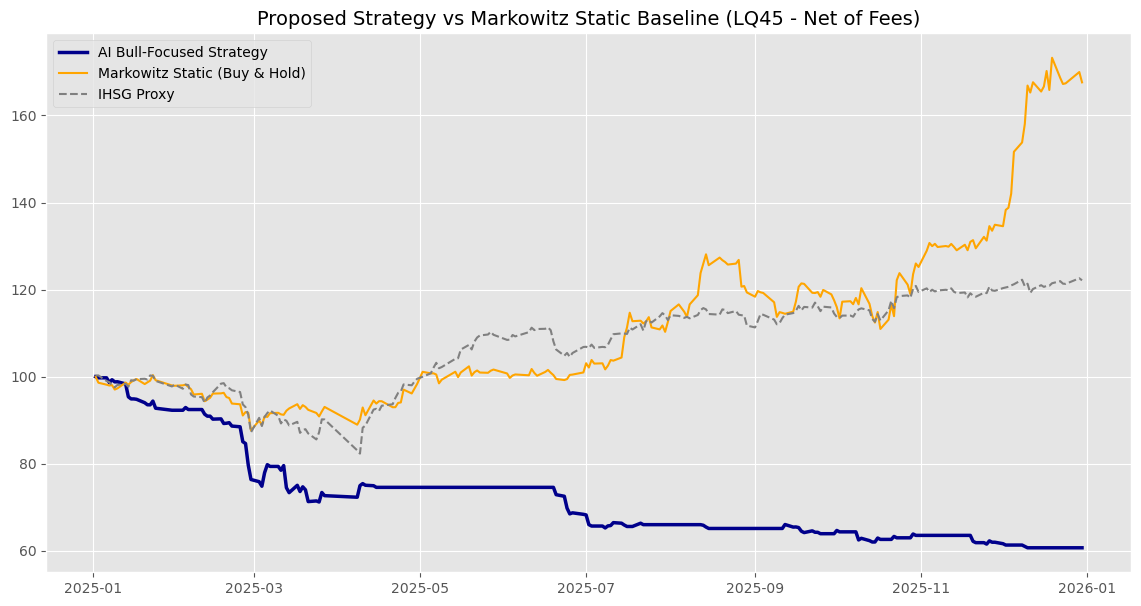

In [4]:
# --- 4. Backtest Comparison ---
test_dates = X_test.index
test_probs = pd.Series(xgb_model.predict_proba(X_test)[:, 1], index=test_dates)
fee = 0.0025

print("Running Simulation: Bull-Focused AI...")
res_ai = run_simulation('Proposed AI', test_dates, returns, test_probs, threshold=opt_t, fee=fee)

print("Running Simulation: Markowitz Static (LQ45)...")
res_static = run_simulation('Markowitz Static', test_dates, returns, fee=fee)

benchmark = pd.DataFrame({'Portfolio_Value': (market_return.loc[test_dates].cumsum().apply(np.exp) * 100)}, index=test_dates)

plt.figure(figsize=(14, 7))
plt.plot(res_ai.index, res_ai['Portfolio_Value'], label="AI Bull-Focused Strategy", color='darkblue', linewidth=2.5)
plt.plot(res_static.index, res_static['Portfolio_Value'], label="Markowitz Static (Buy & Hold)", color='orange')
plt.plot(benchmark.index, benchmark['Portfolio_Value'], label="IHSG Proxy", linestyle='--', color='gray')
plt.title("Proposed Strategy vs Markowitz Static Baseline (LQ45 - Net of Fees)", fontsize=14)
plt.legend()
plt.show()

In [5]:
# Metrics Table
summary = []
for label, df in [("AI Proposed", res_ai), ("Markowitz Static", res_static), ("IHSG Proxy", benchmark)]:
    r = (df['Portfolio_Value'].iloc[-1] / 100) - 1
    rets = df['Portfolio_Value'].pct_change().dropna()
    sh = (rets.mean() * 252) / (rets.std() * np.sqrt(252))
    mdd = (df['Portfolio_Value'] / df['Portfolio_Value'].cummax() - 1).min()
    summary.append({'Strategy': label, 'Ret %': f"{r:.2%}", 'Sharpe': round(sh, 2), 'MaxDD': f"{mdd:.2%}"})

import pandas as pd
display(pd.DataFrame(summary))

,Strategy,Ret %,Sharpe,MaxDD
0,AI Proposed,-39.29%,-3.05,-39.29%
1,Markowitz Static,67.60%,2.19,-13.38%
2,IHSG Proxy,22.13%,1.14,-17.90%
